In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mping
import random

import os

# Visualisando e manipulando dados

In [2]:
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Deep_Learning\\ID para o jhonny-20260515T045215Z-3-001\\ID para o jhonny"

In [3]:
diretorios = os.listdir(CAMINHO)

# Dicionário chave: diretório, valor: lista de imagens
arquivos = {dir : os.listdir(CAMINHO + "\\" + dir) for dir in diretorios if dir[-4] != "."}
#print(arquivos[list(arquivos.keys())[0]])
# Lista de familias para criar datasets no estilo do tensorflow
lista_familias = list(arquivos.keys())
#print(lista_familias)
arquivos = {dir: arquivos[dir] for dir in arquivos.keys() if len(arquivos[dir]) > 20}
arquivos.keys()




dict_keys(['Arecaceae', 'Bignoniaceae', 'Euphorbiaceae', 'Fabaceae', 'Lauraceae', 'Meliaceae', 'Myrtaceae'])

# Verificando quantidade de imagens por classe

# Criando caminhos no estilo do tensor flow
# FEITO

In [2]:
caminho_test ="C:\\Users\\Nitro\\PyCharmMiscProject\\Projetos_DeepLearning\\Identificador_Plantas_Brasil\\plantas_dataset\\test"
caminho_treino = "C:\\Users\\Nitro\\PyCharmMiscProject\\Projetos_DeepLearning\\Identificador_Plantas_Brasil\\plantas_dataset\\train"
caminho_validation = "C:\\Users\\Nitro\\PyCharmMiscProject\\Projetos_DeepLearning\\Identificador_Plantas_Brasil\\plantas_dataset\\val"

In [5]:
def construir_caminhos(test, train, val):
    for familia in lista_familias:
        os.makedirs(test + "\\" + familia, exist_ok=True)
        os.makedirs(train + "\\" + familia, exist_ok=True)
        os.makedirs(val + "\\" + familia, exist_ok=True)
        print("Pastas de famílias criadas com sucesso!!!")
#construir_caminhos(caminho_test, caminho_treino, caminho_validation)
# Pastas de famílias foram criadas com sucesso

# Criando função que copia fotos
# FEITO

In [6]:
def copy_image(caminho_origem: str, percents, caminho_destino_test: str, caminho_destino_train:str, caminho_destino_val:str):
    import random
    import shutil



    # Variável "arquivos"
    for familia in arquivos.keys():
        print(familia)
        imagens_treino = random.sample(arquivos[familia], int(len(arquivos[familia]) * percents["train"]))
        sobra_treino = [x for x in arquivos[familia] if x not in imagens_treino]
        imagens_teste = random.sample(sobra_treino, int(len(sobra_treino) * 0.66))
        imagens_val = [x for x in sobra_treino if x not in imagens_teste]

        for foto in imagens_treino:
            caminho_completo_origem = CAMINHO + "\\" + familia + "\\" + foto
            caminho_completo_destino_treino = caminho_destino_train + "\\" + familia
            shutil.copy2(caminho_completo_origem, caminho_completo_destino_treino)


        for foto in imagens_teste:
            caminho_completo_origem = CAMINHO + "\\" + familia + "\\" + foto
            caminho_completo_destino_teste = caminho_destino_test + "\\" + familia

            shutil.copy2(caminho_completo_origem, caminho_completo_destino_teste)

        for foto in imagens_val:
            caminho_completo_origem = CAMINHO + "\\" + familia + "\\" + foto
            caminho_completo_destino_val = caminho_destino_val + "\\" + familia

            shutil.copy2(caminho_completo_origem, caminho_completo_destino_val)




    return
#copy_image(CAMINHO, {"test": 0.2, "train": 0.7, "val": 0.1}, caminho_test, caminho_treino, caminho_validation)

# Carregar as imagens para a rede neural

In [4]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [5]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(caminho_treino, image_size=(192, 192), batch_size=32)
val_dataset = image_dataset_from_directory(caminho_validation, image_size=(192, 192), batch_size=32)
test_dataset = image_dataset_from_directory(caminho_test, image_size=(192,192), batch_size=32)

Found 190 files belonging to 7 classes.
Found 33 files belonging to 7 classes.
Found 51 files belonging to 7 classes.


In [6]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    print(data_batch[0].shape)
    break

data batch shape: (32, 192, 192, 3)
labels batch shape: (32,)
(192, 192, 3)


# Treinando o Modelo

In [19]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(input_shape=(192, 192, 3),
                         include_top=False,
                         weights="imagenet")

base_model.trainable = False

model = keras.Sequential([
    keras.Input(shape=(192, 192, 3)),

    #Rescaling(1./255),
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.2),
    RandomContrast(0.1),

    keras.layers.Rescaling(
        scale=1./127.5,
        offset=-1
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(7, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
history = model.fit(train_dataset, epochs=20)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 592ms/step - accuracy: 0.2368 - loss: 2.3938
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3474 - loss: 1.6752
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.4632 - loss: 1.3846
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 615ms/step - accuracy: 0.6105 - loss: 1.1761
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step - accuracy: 0.6316 - loss: 1.0954
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 639ms/step - accuracy: 0.6316 - loss: 1.0208
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 778ms/step - accuracy: 0.6947 - loss: 0.9380
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6737 - loss: 0.8858
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7263 - loss: 0.7731
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.7526 - loss: 0.7496
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7474 - loss: 0.7072
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7842 - loss: 0.6355

# Resultados

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 192, 192, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 192, 192, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_192            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,599 (10.50 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,744 (1.26 MB)

In [22]:
for imagens,labels in train_dataset.take(10):
    loss, acc = model.evaluate(imagens, labels, verbose=0)
    print(f"Acurácia no batch: {acc:.4f}")


Acurácia no batch: 0.9375
Acurácia no batch: 0.8750
Acurácia no batch: 0.9375
Acurácia no batch: 0.8750
Acurácia no batch: 0.9688
Acurácia no batch: 1.0000


In [23]:
train_loss, train_acc = model.evaluate(train_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
test_loss, test_acc = model.evaluate(test_dataset)

print(f"Treino: {train_acc:.2%}")
print(f"Validação: {val_acc:.2%}")
print(f"Teste: {test_acc:.2%}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.9316 - loss: 0.3042
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.6061 - loss: 0.7837
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.7647 - loss: 0.7296
Treino: 93.16%
Validação: 60.61%
Teste: 76.47%


In [24]:
num_epochs = 100

# Salvando Modelo

In [25]:
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath = 'modelh5.keras',
        monitor = 'val_loss', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1)
]

In [26]:
history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs = num_epochs,
                    callbacks=callbacks_list)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9023 - loss: 0.3693
Epoch 1: val_loss improved from None to 0.71154, saving model to modelh5.keras

Epoch 1: finished saving model to modelh5.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.8842 - loss: 0.3854 - val_accuracy: 0.6667 - val_loss: 0.7115
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8238 - loss: 0.5010
Epoch 2: val_loss did not improve from 0.71154
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 676ms/step - accuracy: 0.8579 - loss: 0.4355 - val_accuracy: 0.6970 - val_loss: 0.8035
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.9021 - loss: 0.3769
Epoch 3: val_loss did not improve from 0.71154
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 745ms/step - accuracy: 0.8895 - loss: 0.3754 - val_accuracy: 0.6970 - val_loss: 0.8079
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.8416 - loss: 0.4185
Epoch 4: val_loss did not improve from 0.71154
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 710ms/step - accuracy: 

# Indicadores

[0.8842105269432068, 0.8578947186470032, 0.8894736766815186, 0.8736842274665833, 0.9052631855010986, 0.8842105269432068, 0.9052631855010986, 0.8947368264198303, 0.9105263352394104, 0.8999999761581421, 0.9473684430122375, 0.942105233669281, 0.9105263352394104, 0.8631578683853149, 0.9263157844543457, 0.9526315927505493, 0.9473684430122375, 0.9578947424888611, 0.9263157844543457]


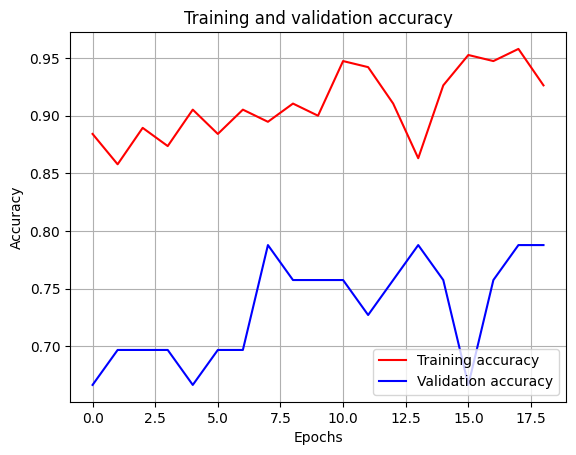

In [27]:
acc = history.history['accuracy']
val_acc = history.history["val_accuracy"]
print(acc)

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label="Training accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation accuracy")

plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.title("Training and validation accuracy")
plt.legend(loc=4)
plt.grid(axis='both')

plt.show()

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

loss, acc = model.evaluate(test_dataset)
print(f"Acurácia no teste: {acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.7255 - loss: 0.7324
Acurácia no teste: 0.7255


# Importando .Keras para minhas fotos

In [29]:
import tensorflow as tf

model_k = tf.keras.models.load_model("modelh5.keras")